<a href="https://colab.research.google.com/github/soup511/OIBSIP/blob/main/SouptikaDas_Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Car Price Prediction with Machine Learning

## Objective

The goal of this project is to build machine learning models that can predict
the selling price of a used car based on features such as its brand, age,
present price, mileage, fuel type, seller type, transmission, and ownership.

In this project, I will clean and explore the dataset, create some useful
features, encode categorical variables, train multiple regression models,
compare their performance, and identify the most important features affecting
car prices.

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

In [54]:

df =pd.read_csv('/content/CAR DETAILS FROM CAR DEKHO.csv')

Load the Dataset

In [55]:
df.head(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


Understand the Dataset

In [56]:
df.shape

(4340, 8)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [58]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [59]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

Check Missing Values

In [60]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


Remove Duplicate Rows

In [61]:
df.duplicated().sum()

np.int64(763)

In [62]:
df=df.drop_duplicates()

In [63]:
df.shape

(3577, 8)

Clean Categorical Variables

In [64]:
categorical_columns = ["Fuel_Type", "Seller_Type", "Transmission", "Owner"]
for column in categorical_columns:
    if column in df.columns:
        df[column] = df[column].astype(str).str.strip()

In [65]:
for column in categorical_columns:
    if column in df.columns:
        print(f"\n{column}:")
        print(df[column].unique())

Feature Engineering

In [66]:
current_year = 2026
df["Car_Age"] = current_year - df["year"]
df[["year", "Car_Age"]].head()

,year,Car_Age
0,2007,19
1,2007,19
2,2012,14
3,2017,9
4,2014,12


In [67]:
df["Brand"] = df["name"].str.split().str[0]
df[["name", "Brand"]].head()

,name,Brand
0,Maruti 800 AC,Maruti
1,Maruti Wagon R LXI Minor,Maruti
2,Hyundai Verna 1.6 SX,Hyundai
3,Datsun RediGO T Option,Datsun
4,Honda Amaze VX i-DTEC,Honda


In [68]:
print("Number of unique brands:", df["Brand"].nunique())

print("\nTop 20 brands:")
print(df["Brand"].value_counts().head(20))

Number of unique brands: 29

Top 20 brands:
Brand
Maruti           1072
Hyundai           637
Mahindra          328
Tata              308
Ford              220
Honda             216
Toyota            170
Chevrolet         151
Renault           110
Volkswagen         93
Nissan             52
Skoda              49
Fiat               32
Audi               31
Datsun             29
BMW                25
Mercedes-Benz      21
Mitsubishi          5
Jaguar              5
Land                5
Name: count, dtype: int64


Basic EDA

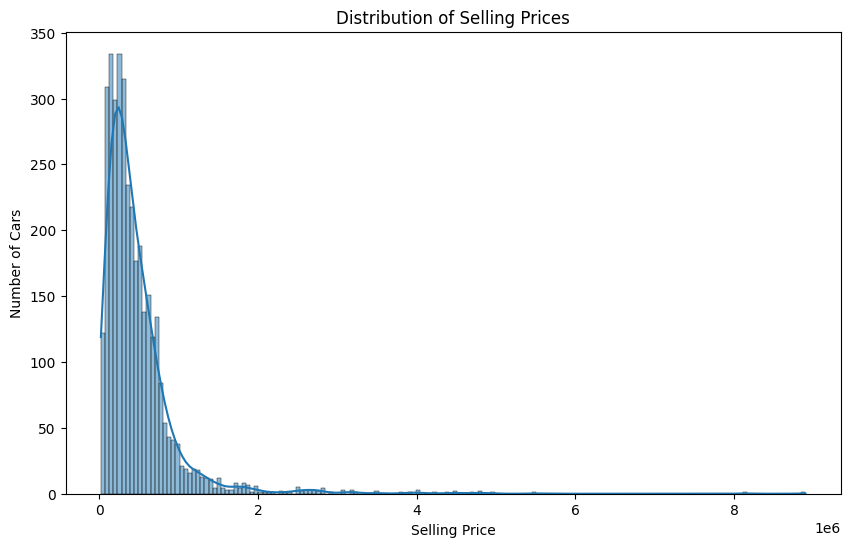

In [69]:
plt.figure(figsize=(10, 6))
sns.histplot(df["selling_price"], kde=True)
plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.show()

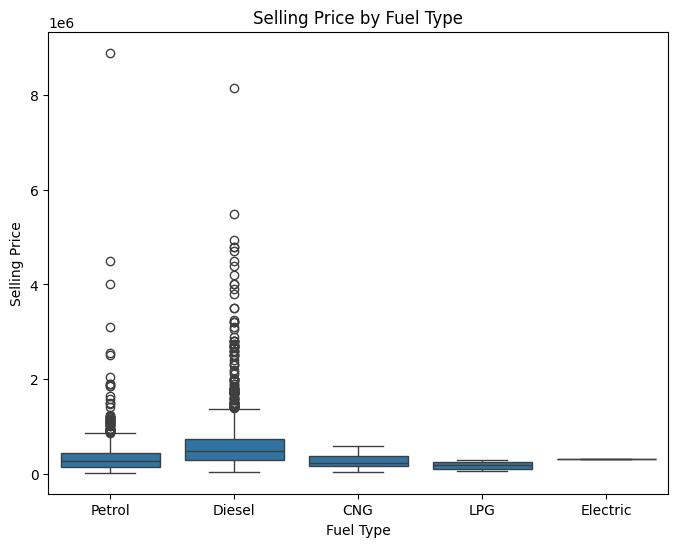

In [70]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="fuel", y="selling_price")
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

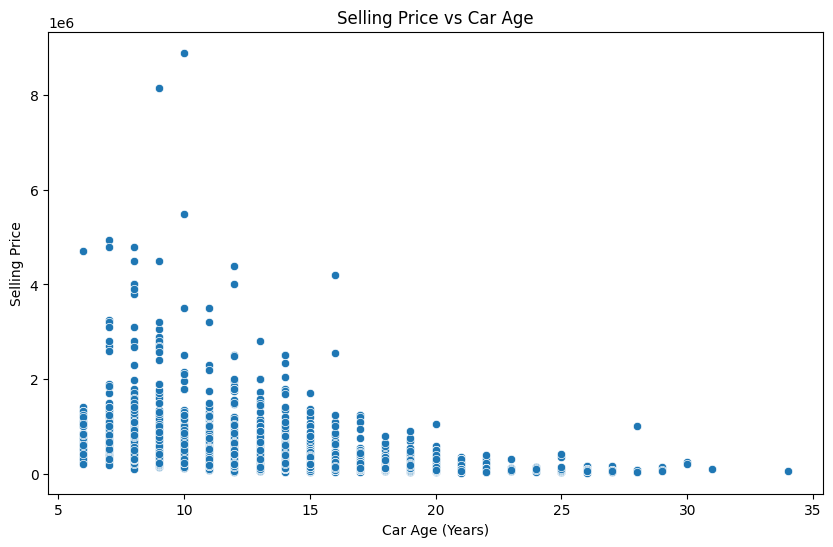

In [71]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Car_Age",
    y="selling_price"
)
plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")
plt.show()

Additional EDA

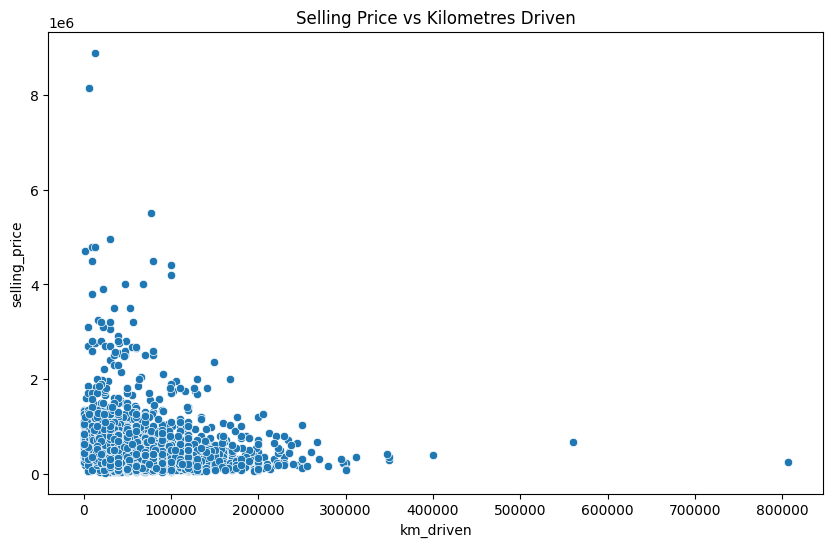

In [115]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="km_driven", y="selling_price")
plt.title("Selling Price vs Kilometres Driven")
plt.show()

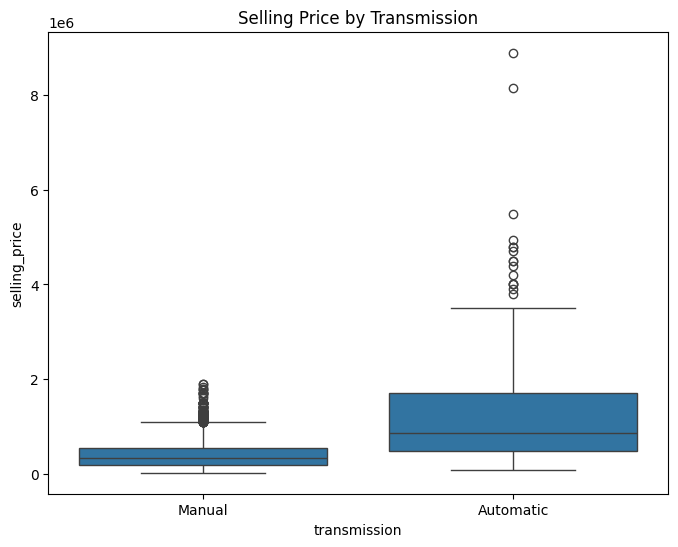

In [116]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="transmission", y="selling_price")
plt.title("Selling Price by Transmission")
plt.show()

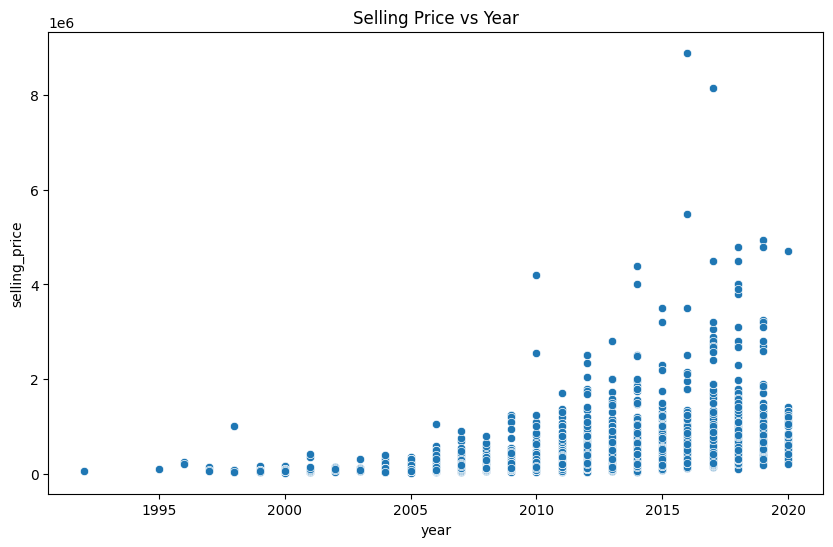

In [117]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="year", y="selling_price")
plt.title("Selling Price vs Year")
plt.show()

Correlation Heatmap

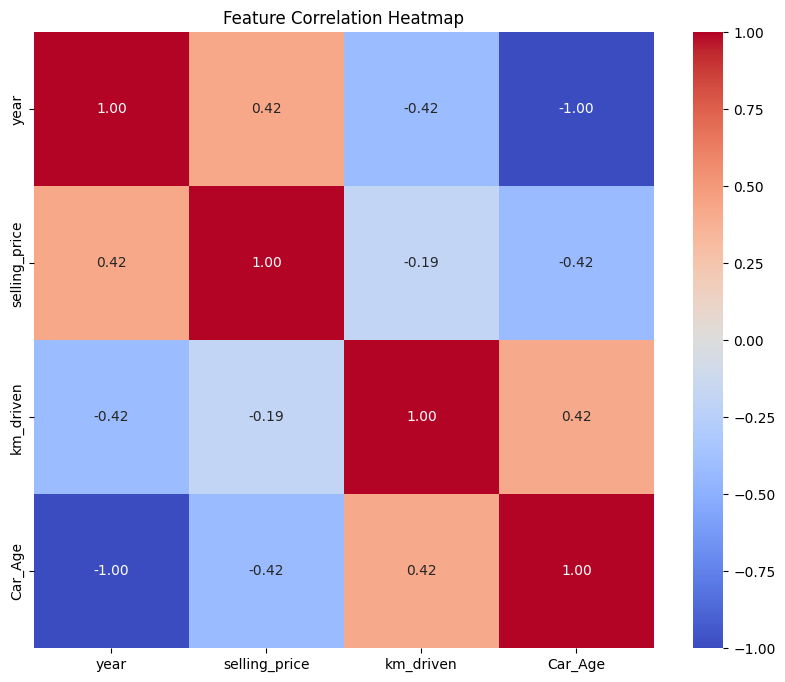

In [79]:
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Feature Correlation Heatmap")
plt.show()

Prepare Features and Target

In [81]:
X = df.drop(columns=["selling_price"])
y = df["selling_price"]
print("Features:")
print(X.columns.tolist())
print("\nTarget:")
print("selling_price")

Features:
['name', 'year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'Car_Age', 'Brand']

Target:
selling_price


In [83]:
X = X.drop(columns=["name", "year"])
X.head()

,km_driven,fuel,seller_type,transmission,owner,Car_Age,Brand
0,70000,Petrol,Individual,Manual,First Owner,19,Maruti
1,50000,Petrol,Individual,Manual,First Owner,19,Maruti
2,100000,Diesel,Individual,Manual,First Owner,14,Hyundai
3,46000,Petrol,Individual,Manual,First Owner,9,Datsun
4,141000,Diesel,Individual,Manual,Second Owner,12,Honda


Identify Numerical and Categorical Features

In [84]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()
print("Categorical features:")
print(categorical_features)
print("\nNumerical features:")
print(numerical_features)

Categorical features:
['fuel', 'seller_type', 'transmission', 'owner', 'Brand']

Numerical features:
['km_driven', 'Car_Age']


Train-Test Split

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 2861
Testing samples: 716


Encode Categorical Variables

In [86]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

Model 1 — Linear Regression

In [87]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)
linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

Evaluate Linear Regression

In [91]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression")
print("MAE:", round(linear_mae, 3))
print("RMSE:", round(linear_rmse, 3))
print("R²:", round(linear_r2, 3))

Linear Regression
MAE: 206368.402
RMSE: 431734.103
R²: 0.421


Model 2 — Random Forest

In [93]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42
            )
        )
    ]
)
random_forest_model.fit(X_train, y_train)
rf_predictions = random_forest_model.predict(X_test)

Evaluate Random Forest

In [94]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest")
print("MAE:", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R²:", round(rf_r2, 3))

Random Forest
MAE: 158385.488
RMSE: 363880.948
R²: 0.589


Optional Model 3 — Gradient Boosting

In [96]:
gradient_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)
gradient_model.fit(X_train, y_train)
gradient_predictions = gradient_model.predict(X_test)

In [97]:
gradient_mae = mean_absolute_error(y_test, gradient_predictions)
gradient_rmse = np.sqrt(mean_squared_error(y_test, gradient_predictions))
gradient_r2 = r2_score(y_test, gradient_predictions)

print("Gradient Boosting")
print("MAE:", round(gradient_mae, 3))
print("RMSE:", round(gradient_rmse, 3))
print("R²:", round(gradient_r2, 3))

Gradient Boosting
MAE: 156904.934
RMSE: 365685.872
R²: 0.585


Compare All Models

In [98]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gradient_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gradient_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2,
        gradient_r2
    ]
})
results = results.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)
results

,Model,MAE,RMSE,R2 Score
0,Random Forest,158385.487799,363880.948148,0.588961
1,Gradient Boosting,156904.934188,365685.872328,0.584873
2,Linear Regression,206368.402081,431734.103002,0.421375


Model Performance Visualization

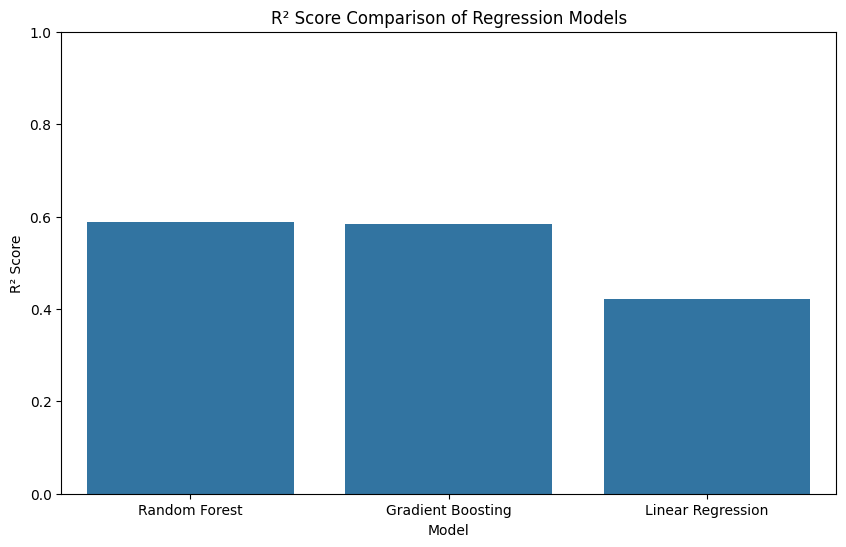

In [101]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)
plt.title("R² Score Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.show()

Actual vs Predicted Prices

In [102]:
best_model_name = results.loc[0, "Model"]
print("Best performing model:", best_model_name)

Best performing model: Random Forest


In [104]:
if best_model_name == "Linear Regression":
    best_predictions = linear_predictions
elif best_model_name == "Random Forest":
    best_predictions = rf_predictions
else:
    best_predictions = gradient_predictions

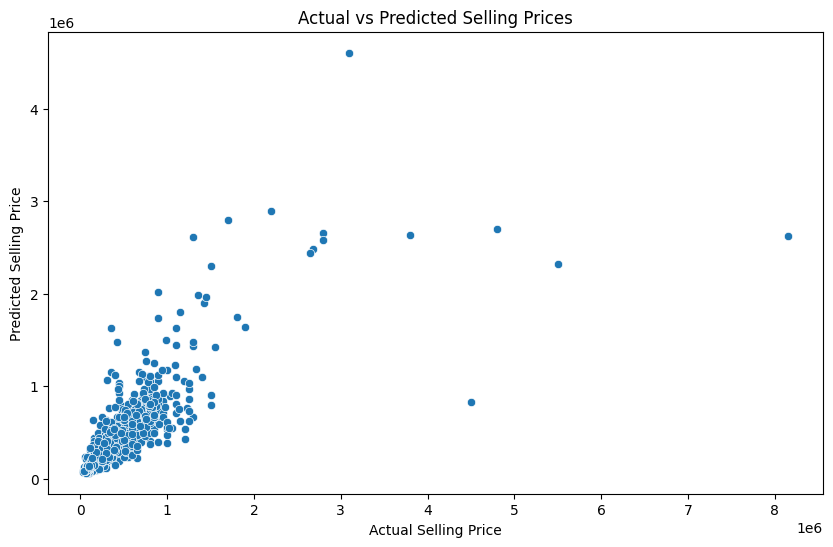

In [105]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=y_test,
    y=best_predictions
)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Prices")
plt.show()

Feature Importance

In [106]:
rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_model = random_forest_model.named_steps["model"]
encoded_feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)
feature_importance = rf_model.feature_importances_
importance_df = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": feature_importance
})
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)
importance_df.head(15)

,Feature,Importance
42,remainder__Car_Age,0.218622
41,remainder__km_driven,0.133800
7,categorical__transmission_Automatic,0.130192
8,categorical__transmission_Manual,0.120423
1,categorical__fuel_Diesel,0.071870
15,categorical__Brand_Audi,0.046756
3,categorical__fuel_Petrol,0.044813
27,categorical__Brand_Land,0.039568
38,categorical__Brand_Toyota,0.036821
16,categorical__Brand_BMW,0.013976


Feature Importance Chart

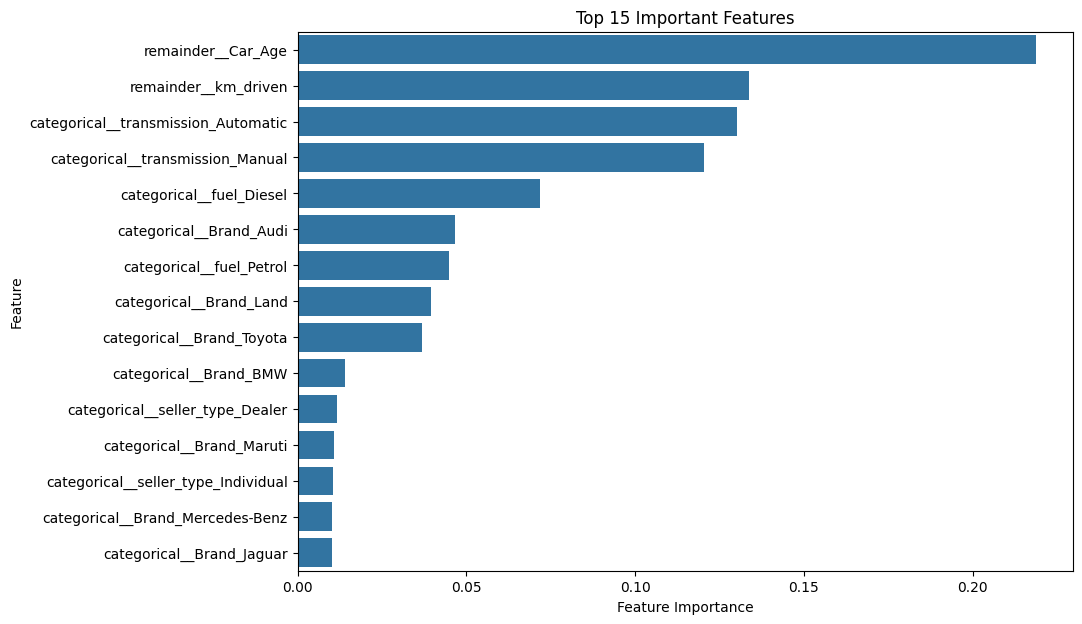

In [107]:
top_features = importance_df.head(15)
plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

Example Prediction

In [110]:
sample_car = pd.DataFrame({
    "km_driven": [30000],
    "fuel": ["Petrol"],
    "seller_type": ["Dealer"],
    "transmission": ["Manual"],
    "owner": ["First Owner"],
    "Car_Age": [5],
    "Brand": ["Toyota"]
})
predicted_price = random_forest_model.predict(sample_car)
print(
    "Predicted Selling Price:",
    round(predicted_price[0], 2)
)

Predicted Selling Price: 939528.04


## Conclusion

In this project, I developed machine learning models to predict the selling
price of used cars.

The dataset was cleaned by checking for missing values, removing duplicate
records, and standardizing categorical information. I also created two useful
features: car age from the manufacturing year and brand from the car name.

Exploratory data analysis helped me understand how factors such as fuel type,
car age, mileage, transmission, and year are related to selling price.

I trained and compared Linear Regression, Random Forest Regression, and
Gradient Boosting Regression models using MAE, RMSE, and R² score.

The model with the highest R² score was selected as the best-performing model.
Feature importance analysis was then used to identify the characteristics that
had the greatest influence on the predicted selling price.

Overall, this project helped me understand the complete machine learning
workflow for a regression problem, from data cleaning and feature engineering
to model training, evaluation, and interpretation.